# 7CUSMNDA-Network-Data-Analysis
created by Hsiang-Yin 04/08/2026

## Part 1 - Task A

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from collections import defaultdict

In [3]:
# =========================================================
# 1. BUILD EDITOR NETWORK
# =========================================================
def build_editor_network(
    filepath,
    page_col="page_name",
    thread_col="thread_subject",
    user_col="username",
    keep_shared_discussions=False
):
    df = pd.read_csv(filepath)

    # Basic cleaning
    df = df[[page_col, thread_col, user_col]].dropna().drop_duplicates()
    df[page_col] = df[page_col].astype(str).str.strip()
    df[thread_col] = df[thread_col].astype(str).str.strip()
    df[user_col] = df[user_col].astype(str).str.strip()

    # Remove empty strings after stripping
    df = df[
        (df[page_col] != "") &
        (df[thread_col] != "") &
        (df[user_col] != "")
    ].copy()

    # User statistics
    user_comment_count = df[user_col].value_counts().to_dict()
    user_discussion_count = (
        df.groupby(user_col)[[page_col, thread_col]]
        .apply(lambda x: len(set(map(tuple, x.values.tolist()))))
        .to_dict()
    )

    # User-ID mapping
    users = sorted(df[user_col].unique())
    user_to_id = {u: i for i, u in enumerate(users)}
    id_to_user = {i: u for u, i in user_to_id.items()}

    # Group by page-thread
    grouped = df.groupby([page_col, thread_col])[user_col].apply(lambda s: sorted(set(s)))

    edge_weights = defaultdict(int)
    shared_discussions = defaultdict(list) if keep_shared_discussions else None

    # Build weighted co-participation edges
    for (page, thread), participants in grouped.items():
        if len(participants) < 2:
            continue

        ids = [user_to_id[u] for u in participants]

        for u, v in combinations(sorted(ids), 2):
            edge_weights[(u, v)] += 1
            if keep_shared_discussions:
                shared_discussions[(u, v)].append((page, thread))

    # Create graph
    G = nx.Graph()

    for user, node_id in user_to_id.items():
        G.add_node(
            node_id,
            username=user,
            comment_count=user_comment_count.get(user, 0),
            discussion_count=user_discussion_count.get(user, 0)
        )

    for (u, v), w in edge_weights.items():
        attrs = {"weight": w}
        if keep_shared_discussions:
            attrs["shared_discussions"] = shared_discussions[(u, v)]
        G.add_edge(u, v, **attrs)

    return G, df, grouped, user_to_id, id_to_user, user_comment_count, user_discussion_count


# =========================================================
# 2. TASK A SUMMARY
# =========================================================
def compute_taskA_summary(G, df, grouped, page_col="page_name", thread_col="thread_subject"):
    n_users = G.number_of_nodes()
    n_edges = G.number_of_edges()
    n_components = nx.number_connected_components(G) if n_users > 0 else 0
    n_isolates = nx.number_of_isolates(G) if n_users > 0 else 0

    if n_users > 0:
        largest_cc_size = len(max(nx.connected_components(G), key=len))
        largest_component_ratio = largest_cc_size / n_users
        density = nx.density(G)
        avg_degree = sum(dict(G.degree()).values()) / n_users
    else:
        largest_cc_size = 0
        largest_component_ratio = 0
        density = 0
        avg_degree = 0

    summary = {
        "rows_after_cleaning": len(df),
        "n_users": n_users,
        "n_edges": n_edges,
        "n_pages": df[page_col].nunique(),
        "n_threads": df[thread_col].nunique(),
        "n_page_thread_groups": grouped.shape[0],
        "n_components": n_components,
        "n_isolates": n_isolates,
        "largest_component_size": largest_cc_size,
        "largest_component_ratio": largest_component_ratio,
        "density": density,
        "avg_degree": avg_degree
    }

    return summary


# =========================================================
# 3. LARGEST CONNECTED COMPONENT
# =========================================================
def get_largest_component_graph(G):
    if G.number_of_nodes() == 0:
        return None
    largest_cc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc_nodes).copy()


def get_largest_component_subgraph_for_plot(G, max_nodes_for_plot=200):
    H = get_largest_component_graph(G)
    if H is None:
        return None

    if H.number_of_nodes() > max_nodes_for_plot:
        top_nodes = sorted(H.degree, key=lambda x: x[1], reverse=True)[:max_nodes_for_plot]
        keep_nodes = [n for n, _ in top_nodes]
        H = H.subgraph(keep_nodes).copy()

    return H


# =========================================================
# 4. TASK A FIGURE: COMBINED NETWORK PLOT
# =========================================================
def plot_largest_components_combined(
    results,
    output_path="part1_taskA_largest_components.png",
    max_nodes_for_plot=200
):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes = axes.flatten()

    for ax, (name, res) in zip(axes, results.items()):
        G = res["graph"]
        H = get_largest_component_subgraph_for_plot(G, max_nodes_for_plot=max_nodes_for_plot)

        if H is None or H.number_of_nodes() == 0:
            ax.set_title(f"{name} - empty graph")
            ax.axis("off")
            continue

        pos = nx.spring_layout(H, seed=42)

        node_sizes = [20 + 5 * H.degree(n) for n in H.nodes()]
        edge_widths = [0.3 + 0.15 * H[u][v].get("weight", 1) for u, v in H.edges()]

        nx.draw_networkx_nodes(
            H, pos, ax=ax,
            node_size=node_sizes,
            alpha=0.8
        )
        nx.draw_networkx_edges(
            H, pos, ax=ax,
            width=edge_widths,
            alpha=0.35
        )

        ax.set_title(f"{name} - largest component", fontsize=14)
        ax.axis("off")

    plt.tight_layout()
    # plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

## Part 1 - Task B

In [4]:
# =========================================================
# 5. TASK B METRICS
# =========================================================
def compute_taskB_metrics(G, n_random=10, seed=42):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    if n == 0:
        return {
            "n": 0,
            "m": 0,
            "density": 0,
            "avg_degree": 0,
            "largest_component_size": 0,
            "largest_component_ratio": 0,
            "avg_clustering": 0,
            "avg_shortest_path_lcc": np.nan,
            "diameter_lcc": np.nan,
            "degree_std": 0,
            "max_degree": 0,
            "C_rand": np.nan,
            "L_rand": np.nan,
            "small_world_index": np.nan
        }

    degrees = np.array([d for _, d in G.degree()])
    avg_degree = degrees.mean()
    degree_std = degrees.std()
    max_degree = degrees.max()
    density = nx.density(G)

    H = get_largest_component_graph(G)
    lcc_size = H.number_of_nodes()
    lcc_ratio = lcc_size / n

    avg_clustering = nx.average_clustering(G)

    if H.number_of_nodes() > 1:
        avg_shortest_path_lcc = nx.average_shortest_path_length(H)
        diameter_lcc = nx.diameter(H)
    else:
        avg_shortest_path_lcc = np.nan
        diameter_lcc = np.nan

    # Random graph comparison: G(n, m)
    rand_clusterings = []
    rand_path_lengths = []
    rng = np.random.default_rng(seed)

    for _ in range(n_random):
        Gr = nx.gnm_random_graph(n, m, seed=int(rng.integers(0, 10**9)))
        rand_clusterings.append(nx.average_clustering(Gr))

        Hr = get_largest_component_graph(Gr)
        if Hr is not None and Hr.number_of_nodes() > 1:
            rand_path_lengths.append(nx.average_shortest_path_length(Hr))

    C_rand = np.mean(rand_clusterings) if rand_clusterings else np.nan
    L_rand = np.mean(rand_path_lengths) if rand_path_lengths else np.nan

    if C_rand > 0 and L_rand > 0 and not np.isnan(avg_shortest_path_lcc):
        small_world_index = (avg_clustering / C_rand) / (avg_shortest_path_lcc / L_rand)
    else:
        small_world_index = np.nan

    return {
        "n": n,
        "m": m,
        "density": density,
        "avg_degree": avg_degree,
        "largest_component_size": lcc_size,
        "largest_component_ratio": lcc_ratio,
        "avg_clustering": avg_clustering,
        "avg_shortest_path_lcc": avg_shortest_path_lcc,
        "diameter_lcc": diameter_lcc,
        "degree_std": degree_std,
        "max_degree": max_degree,
        "C_rand": C_rand,
        "L_rand": L_rand,
        "small_world_index": small_world_index
    }


# =========================================================
# 6. TASK B FIGURE: DEGREE DISTRIBUTIONS
# =========================================================
def plot_degree_distributions(results, output_path="part1_taskB_degree_distributions.png"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes = axes.flatten()

    for ax, (name, res) in zip(axes, results.items()):
        G = res["graph"]
        degrees = [d for _, d in G.degree()]

        ax.hist(degrees, bins=30)
        ax.set_title(name)
        ax.set_xlabel("Degree")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    # plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# =========================================================
# 7. TASK B FIGURE: REAL VS RANDOM
# =========================================================
def plot_taskB_comparison(taskB_df, output_path="part1_taskB_real_vs_random.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    x = np.arange(len(taskB_df.index))
    width = 0.35

    # Clustering comparison
    axes[0].bar(x - width/2, taskB_df["avg_clustering"], width, label="Real")
    axes[0].bar(x + width/2, taskB_df["C_rand"], width, label="Random")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(taskB_df.index)
    axes[0].set_title("Average clustering: Real vs Random")
    axes[0].set_ylabel("Clustering coefficient")
    axes[0].legend()

    # Path length comparison
    axes[1].bar(x - width/2, taskB_df["avg_shortest_path_lcc"], width, label="Real")
    axes[1].bar(x + width/2, taskB_df["L_rand"], width, label="Random")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(taskB_df.index)
    axes[1].set_title("Average shortest path (LCC): Real vs Random")
    axes[1].set_ylabel("Average shortest path length")
    axes[1].legend()

    plt.tight_layout()
    # plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

## Part 1 - Task C

In [5]:

def get_node_strength(G):
    """Weighted degree (sum of edge weights)."""
    strength = {}
    for n in G.nodes():
        strength[n] = sum(data.get("weight", 1) for _, _, data in G.edges(n, data=True))
    return strength


def jaccard_similarity_neighbors(G, u, v):
    """Jaccard similarity based on 1-hop neighbor sets."""
    Nu = set(G.neighbors(u))
    Nv = set(G.neighbors(v))
    union = Nu | Nv
    if len(union) == 0:
        return 0.0
    return len(Nu & Nv) / len(union)


def shared_neighbor_count(G, u, v):
    return len(list(nx.common_neighbors(G, u, v)))


def safe_shortest_path_length(G, source, target):
    try:
        return nx.shortest_path_length(G, source=source, target=target)
    except nx.NetworkXNoPath:
        return np.inf


def risk_score_from_source(
    G,
    source,
    alpha_distance=1.0,
    beta_similarity=1.0,
    gamma_shared=0.3,
    delta_weight=0.3,
    epsilon_activity=0.2,
    normalize=True
):
    """
    Compute per-node propagation risk from a single suspected editor.

    Components:
    - distance effect: closer nodes are riskier
    - structural similarity: Jaccard similarity of neighborhoods
    - shared neighbors: overlap in local structure
    - direct edge weight: stronger co-participation tie => more risk
    - activity/strength: more active nodes can receive/propagate faster
    """
    strength = get_node_strength(G)
    max_strength = max(strength.values()) if len(strength) > 0 else 1

    scores = {}

    for v in G.nodes():
        if v == source:
            continue

        d = safe_shortest_path_length(G, source, v)
        if np.isinf(d):
            distance_component = 0.0
        else:
            distance_component = 1 / (1 + d)

        similarity_component = jaccard_similarity_neighbors(G, source, v)
        shared_component = shared_neighbor_count(G, source, v)

        if G.has_edge(source, v):
            weight_component = G[source][v].get("weight", 1)
        else:
            weight_component = 0

        activity_component = strength.get(v, 0) / max_strength if max_strength > 0 else 0

        score = (
            alpha_distance * distance_component +
            beta_similarity * similarity_component +
            gamma_shared * shared_component +
            delta_weight * weight_component +
            epsilon_activity * activity_component
        )
        scores[v] = score

    if normalize and len(scores) > 0:
        max_score = max(scores.values())
        if max_score > 0:
            scores = {k: v / max_score for k, v in scores.items()}

    return scores


def combine_dual_source_scores(scores_a, scores_b, mode="sum"):
    """
    Combine risk scores from two suspected editors.
    mode:
    - 'sum': high risk if close to either or both
    - 'product': highest when close to both
    - 'max': dominated by whichever source is more influential
    """
    nodes = set(scores_a.keys()) | set(scores_b.keys())
    combined = {}

    for n in nodes:
        a = scores_a.get(n, 0)
        b = scores_b.get(n, 0)

        if mode == "product":
            combined[n] = a * b
        elif mode == "max":
            combined[n] = max(a, b)
        else:
            combined[n] = a + b

    if len(combined) > 0:
        max_score = max(combined.values())
        if max_score > 0:
            combined = {k: v / max_score for k, v in combined.items()}

    return combined


def estimate_non_propagation_plausibility(
    G,
    suspected_nodes,
    top_k_neighbors=10
):
    """
    Heuristic answer to:
    'How plausible is it that the behavior has not propagated yet to neighboring similar editors?'

    Idea:
    - look at high-risk neighboring/similar nodes
    - if many high-risk nearby nodes exist, non-propagation is less plausible
    """
    if len(suspected_nodes) == 1:
        scores = risk_score_from_source(G, suspected_nodes[0])
    elif len(suspected_nodes) == 2:
        s1 = risk_score_from_source(G, suspected_nodes[0])
        s2 = risk_score_from_source(G, suspected_nodes[1])
        scores = combine_dual_source_scores(s1, s2, mode="product")
    else:
        raise ValueError("suspected_nodes must contain 1 or 2 nodes.")

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_nodes = ranked[:top_k_neighbors]

    if len(top_nodes) == 0:
        return {
            "mean_top_risk": 0,
            "high_risk_count": 0,
            "non_propagation_plausibility": "High",
            "ranked_top_nodes": top_nodes
        }

    mean_top_risk = np.mean([score for _, score in top_nodes])
    high_risk_count = sum(score >= 0.6 for _, score in top_nodes)

    # heuristic interpretation
    if mean_top_risk >= 0.65 or high_risk_count >= max(3, top_k_neighbors // 3):
        plausibility = "Low"
    elif mean_top_risk >= 0.4:
        plausibility = "Moderate"
    else:
        plausibility = "High"

    return {
        "mean_top_risk": mean_top_risk,
        "high_risk_count": high_risk_count,
        "non_propagation_plausibility": plausibility,
        "ranked_top_nodes": top_nodes
    }


def build_priority_table(
    G,
    id_to_user,
    suspected_nodes,
    top_n=20,
    dual_mode="product"
):
    """
    Create a ranked list of editors to check next.
    """
    if len(suspected_nodes) == 1:
        scores = risk_score_from_source(G, suspected_nodes[0])
    elif len(suspected_nodes) == 2:
        s1 = risk_score_from_source(G, suspected_nodes[0])
        s2 = risk_score_from_source(G, suspected_nodes[1])
        scores = combine_dual_source_scores(s1, s2, mode=dual_mode)
    else:
        raise ValueError("suspected_nodes must contain 1 or 2 nodes.")

    strength = get_node_strength(G)
    rows = []

    for node, score in scores.items():
        dists = [safe_shortest_path_length(G, s, node) for s in suspected_nodes]
        min_dist = min(dists) if len(dists) > 0 else np.inf

        rows.append({
            "node_id": node,
            "username": id_to_user.get(node, str(node)),
            "risk_score": score,
            "degree": G.degree(node),
            "strength": strength.get(node, 0),
            "min_distance_to_suspected": min_dist
        })

    priority_df = pd.DataFrame(rows).sort_values(
        by=["risk_score", "strength", "degree"],
        ascending=[False, False, False]
    ).head(top_n)

    return priority_df.reset_index(drop=True)


def simulate_sir_on_graph(
    G,
    infected_seeds,
    beta=0.25,
    gamma=0.15,
    n_steps=8,
    use_weights=True,
    seed=42
):
    """
    Simple SIR simulation over the co-participation network.
    beta  = infection probability base
    gamma = recovery probability
    """
    rng = np.random.default_rng(seed)

    state = {n: "S" for n in G.nodes()}
    for s in infected_seeds:
        state[s] = "I"

    history = []

    max_w = max([data.get("weight", 1) for _, _, data in G.edges(data=True)], default=1)

    for t in range(n_steps):
        counts = {
            "step": t,
            "S": sum(1 for x in state.values() if x == "S"),
            "I": sum(1 for x in state.values() if x == "I"),
            "R": sum(1 for x in state.values() if x == "R")
        }
        history.append(counts)

        new_state = state.copy()

        for u in G.nodes():
            if state[u] == "I":
                # spread to susceptible neighbors
                for v in G.neighbors(u):
                    if state[v] == "S":
                        w = G[u][v].get("weight", 1)
                        infection_prob = beta * (w / max_w) if use_weights and max_w > 0 else beta
                        infection_prob = min(infection_prob, 1.0)

                        if rng.random() < infection_prob:
                            new_state[v] = "I"

                # recover
                if rng.random() < gamma:
                    new_state[u] = "R"

        state = new_state

    # final state
    history.append({
        "step": n_steps,
        "S": sum(1 for x in state.values() if x == "S"),
        "I": sum(1 for x in state.values() if x == "I"),
        "R": sum(1 for x in state.values() if x == "R")
    })

    return pd.DataFrame(history)


def choose_example_suspects(G, mode="top_degree"):
    """
    Pick example suspicious nodes for demonstration.
    mode:
    - top_degree: two highest-degree nodes
    - random_connected: two random nodes from LCC
    """
    if G.number_of_nodes() == 0:
        return []

    if mode == "top_degree":
        ranked = sorted(G.degree, key=lambda x: x[1], reverse=True)
        return [ranked[0][0], ranked[1][0]]

    H = get_largest_component_graph(G)
    nodes = list(H.nodes())
    rng = np.random.default_rng(42)
    if len(nodes) >= 2:
        return list(rng.choice(nodes, size=2, replace=False))
    elif len(nodes) == 1:
        return [nodes[0]]
    return []


def plot_taskC_risk_network(
    G,
    priority_df,
    suspected_nodes,
    id_to_user,
    output_path="taskC_risk_network.png",
    top_n=20
):
    """
    Plot suspected nodes + top risk nodes within an induced subgraph.
    """
    top_nodes = priority_df.head(top_n)["node_id"].tolist()
    plot_nodes = set(top_nodes) | set(suspected_nodes)

    # also include edges among them and their immediate neighbors for context
    context_nodes = set(plot_nodes)
    for n in list(plot_nodes):
        context_nodes.update(G.neighbors(n))

    H = G.subgraph(context_nodes).copy()

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(H, seed=42)

    node_sizes = []
    node_colors = []

    top_node_set = set(top_nodes)
    suspected_set = set(suspected_nodes)

    for n in H.nodes():
        if n in suspected_set:
            node_sizes.append(450)
            node_colors.append("red")
        elif n in top_node_set:
            node_sizes.append(220)
            node_colors.append("orange")
        else:
            node_sizes.append(70)
            node_colors.append("lightblue")

    nx.draw_networkx_edges(H, pos, alpha=0.25, width=0.8)
    nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)

    labels = {}
    for n in suspected_set:
        labels[n] = id_to_user.get(n, str(n))
    for n in top_nodes[:8]:
        labels[n] = id_to_user.get(n, str(n))

    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8)

    plt.title("Task C: suspected editors and high-risk neighbors")
    plt.axis("off")
    plt.tight_layout()
    # plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def run_taskC_analysis_for_dataset(
    G,
    id_to_user,
    dataset_name,
    suspected_nodes=None,
    suspect_mode="top_degree",
    top_n_priority=20,
    save_prefix="part1_taskC"
):
    """
    Full Task C pipeline for one dataset.
    """
    if suspected_nodes is None:
        suspected_nodes = choose_example_suspects(G, mode=suspect_mode)

    if len(suspected_nodes) == 0:
        return None

    # one-suspect analysis
    single_priority_df = build_priority_table(
        G, id_to_user, [suspected_nodes[0]], top_n=top_n_priority
    )

    single_plausibility = estimate_non_propagation_plausibility(
        G, [suspected_nodes[0]], top_k_neighbors=10
    )

    # two-suspect analysis (if available)
    dual_priority_df = None
    dual_plausibility = None
    dual_sir_df = None

    if len(suspected_nodes) >= 2:
        dual_priority_df = build_priority_table(
            G, id_to_user, suspected_nodes[:2], top_n=top_n_priority, dual_mode="product"
        )

        dual_plausibility = estimate_non_propagation_plausibility(
            G, suspected_nodes[:2], top_k_neighbors=10
        )

        dual_sir_df = simulate_sir_on_graph(
            G,
            infected_seeds=suspected_nodes[:2],
            beta=0.25,
            gamma=0.15,
            n_steps=8,
            use_weights=True,
            seed=42
        )

    single_sir_df = simulate_sir_on_graph(
        G,
        infected_seeds=[suspected_nodes[0]],
        beta=0.25,
        gamma=0.15,
        n_steps=8,
        use_weights=True,
        seed=42
    )

    # save outputs
    single_priority_df.to_csv(f"{save_prefix}_{dataset_name}_single_priority.csv", index=False)

    if dual_priority_df is not None:
        dual_priority_df.to_csv(f"{save_prefix}_{dataset_name}_dual_priority.csv", index=False)

    single_sir_df.to_csv(f"{save_prefix}_{dataset_name}_single_sir.csv", index=False)

    if dual_sir_df is not None:
        dual_sir_df.to_csv(f"{save_prefix}_{dataset_name}_dual_sir.csv", index=False)

    # plot risk network using dual if available, otherwise single
    plot_df = dual_priority_df if dual_priority_df is not None else single_priority_df
    plot_suspects = suspected_nodes[:2] if len(suspected_nodes) >= 2 else [suspected_nodes[0]]

    plot_taskC_risk_network(
        G,
        plot_df,
        plot_suspects,
        id_to_user,
        output_path=f"{save_prefix}_{dataset_name}_risk_network.png",
        top_n=20
    )

    return {
        "dataset_name": dataset_name,
        "suspected_nodes": suspected_nodes,
        "suspected_usernames": [id_to_user.get(n, str(n)) for n in suspected_nodes],
        "single_priority_df": single_priority_df,
        "single_plausibility": single_plausibility,
        "single_sir_df": single_sir_df,
        "dual_priority_df": dual_priority_df,
        "dual_plausibility": dual_plausibility,
        "dual_sir_df": dual_sir_df
    }


def plot_taskC_sir_curves(taskC_output, dataset_name, output_path):
    plt.figure(figsize=(8, 5))

    single_sir_df = taskC_output["single_sir_df"]
    plt.plot(single_sir_df["step"], single_sir_df["S"], label="S (single suspect)")
    plt.plot(single_sir_df["step"], single_sir_df["I"], label="I (single suspect)")
    plt.plot(single_sir_df["step"], single_sir_df["R"], label="R (single suspect)")

    if taskC_output["dual_sir_df"] is not None:
        dual_sir_df = taskC_output["dual_sir_df"]
        plt.plot(dual_sir_df["step"], dual_sir_df["I"], linestyle="--", label="I (two suspects)")
        plt.plot(dual_sir_df["step"], dual_sir_df["R"], linestyle="--", label="R (two suspects)")

    plt.title(f"Task C SIR simulation - {dataset_name}")
    plt.xlabel("Step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.tight_layout()
    # plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

Processing BOT_REQUESTS ...
Processing PROPERTIES ...
Processing PROJECT_CHAT ...

=== Task A Summary Table ===
              rows_after_cleaning  n_users  n_edges  n_pages  n_threads  \
BOT_REQUESTS               2981.0    552.0   2424.0    108.0     1113.0   
PROPERTIES                13398.0   1942.0   9198.0   2544.0     5785.0   
PROJECT_CHAT              48551.0   4136.0  40255.0    131.0    14916.0   

              n_page_thread_groups  n_components  n_isolates  \
BOT_REQUESTS                1126.0          29.0        25.0   
PROPERTIES                  6681.0         304.0       285.0   
PROJECT_CHAT               15412.0         203.0       195.0   

              largest_component_size  largest_component_ratio  density  \
BOT_REQUESTS                   519.0                    0.940  0.01594   
PROPERTIES                    1618.0                    0.833  0.00488   
PROJECT_CHAT                  3924.0                    0.949  0.00471   

              avg_degree  
BOT_RE

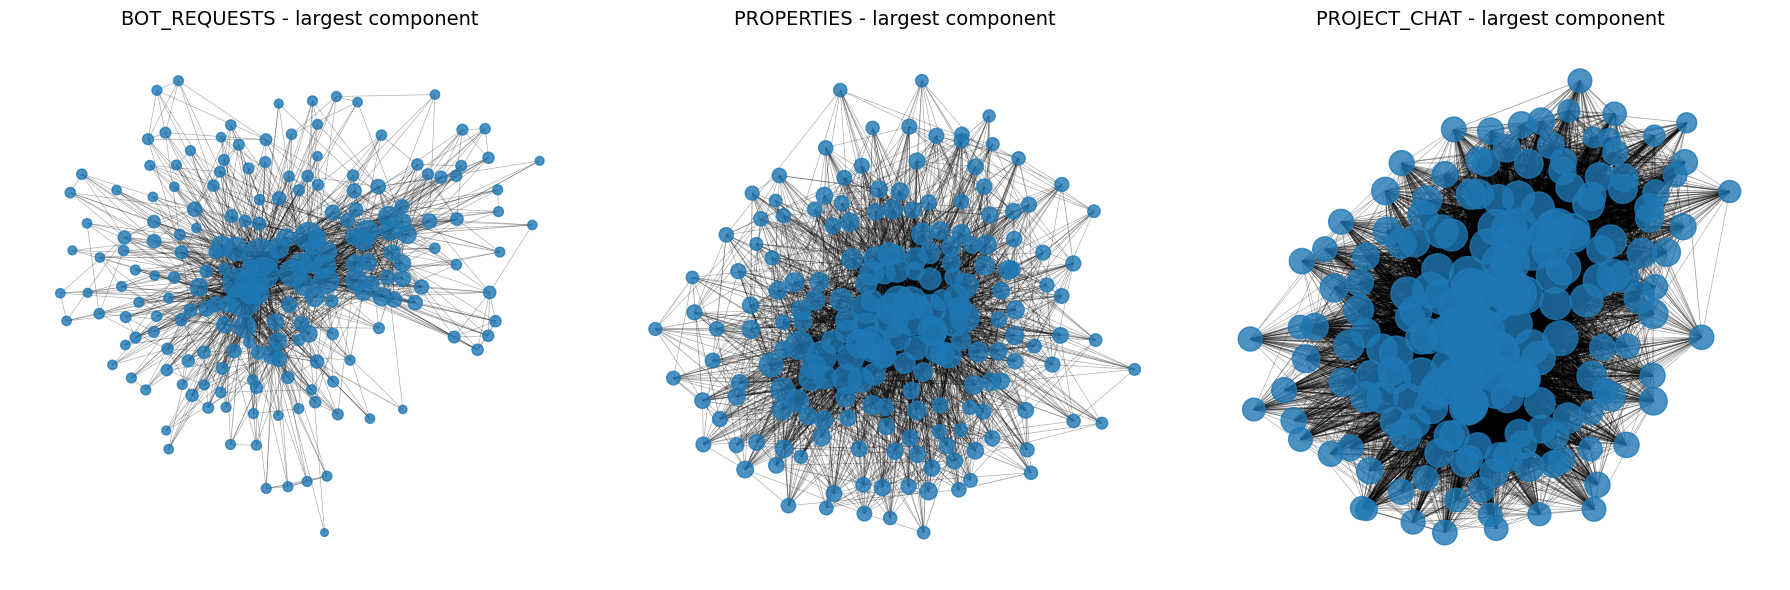


=== Task B Summary Table ===
                   n        m  density  avg_degree  largest_component_size  \
BOT_REQUESTS   552.0   2424.0   0.0159      8.7826                   519.0   
PROPERTIES    1942.0   9198.0   0.0049      9.4727                  1618.0   
PROJECT_CHAT  4136.0  40255.0   0.0047     19.4657                  3924.0   

              largest_component_ratio  avg_clustering  avg_shortest_path_lcc  \
BOT_REQUESTS                   0.9402          0.6576                 2.6028   
PROPERTIES                     0.8332          0.4705                 2.9009   
PROJECT_CHAT                   0.9487          0.6671                 2.7406   

              diameter_lcc  degree_std  max_degree  C_rand  L_rand  \
BOT_REQUESTS           6.0     18.6147       226.0  0.0157  3.1416   
PROPERTIES             7.0     24.5827       627.0  0.0049  3.6185   
PROJECT_CHAT           6.0     58.8715      1166.0  0.0047  3.0826   

              small_world_index  
BOT_REQUESTS         

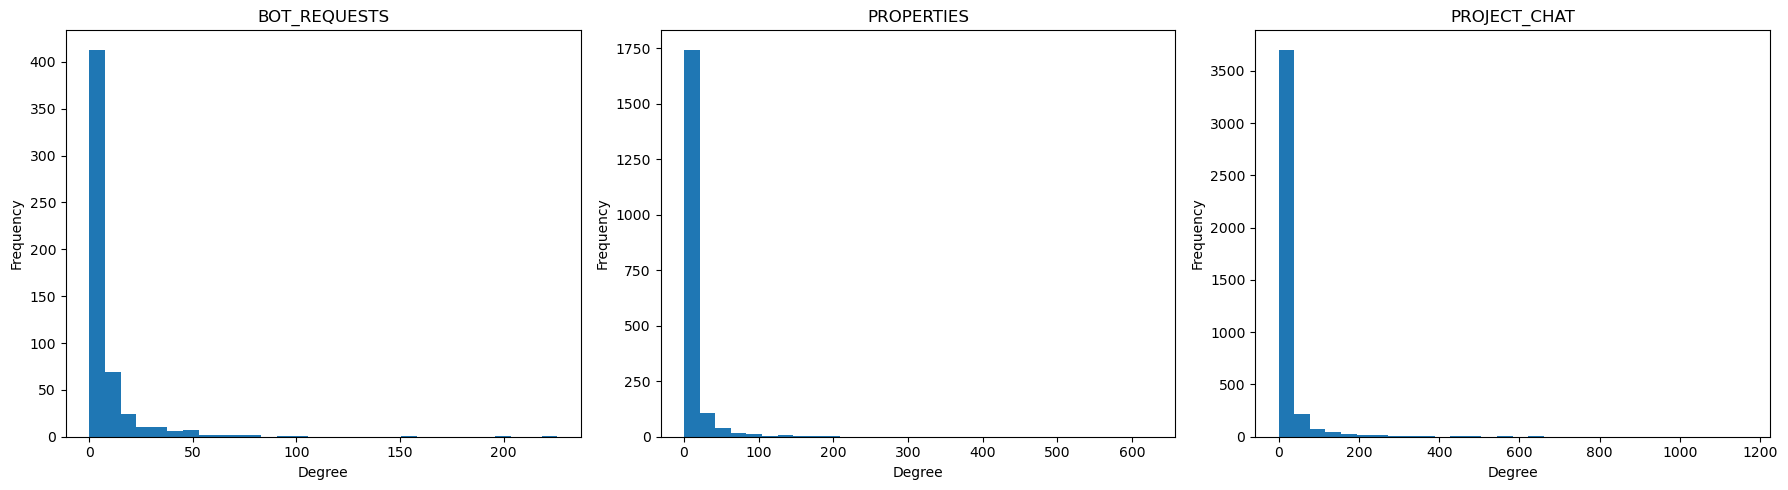

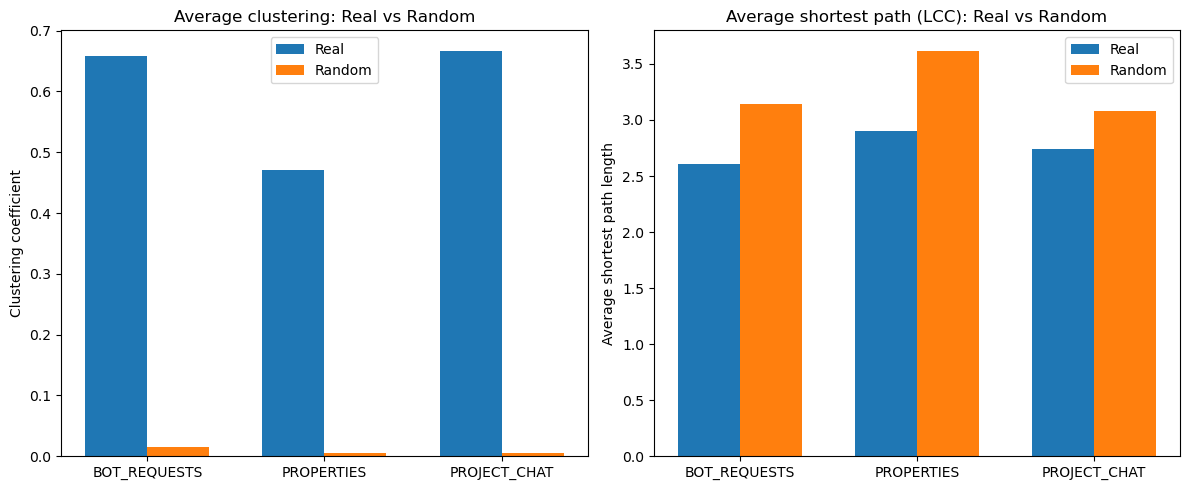


=== Task C: BOT_REQUESTS ===


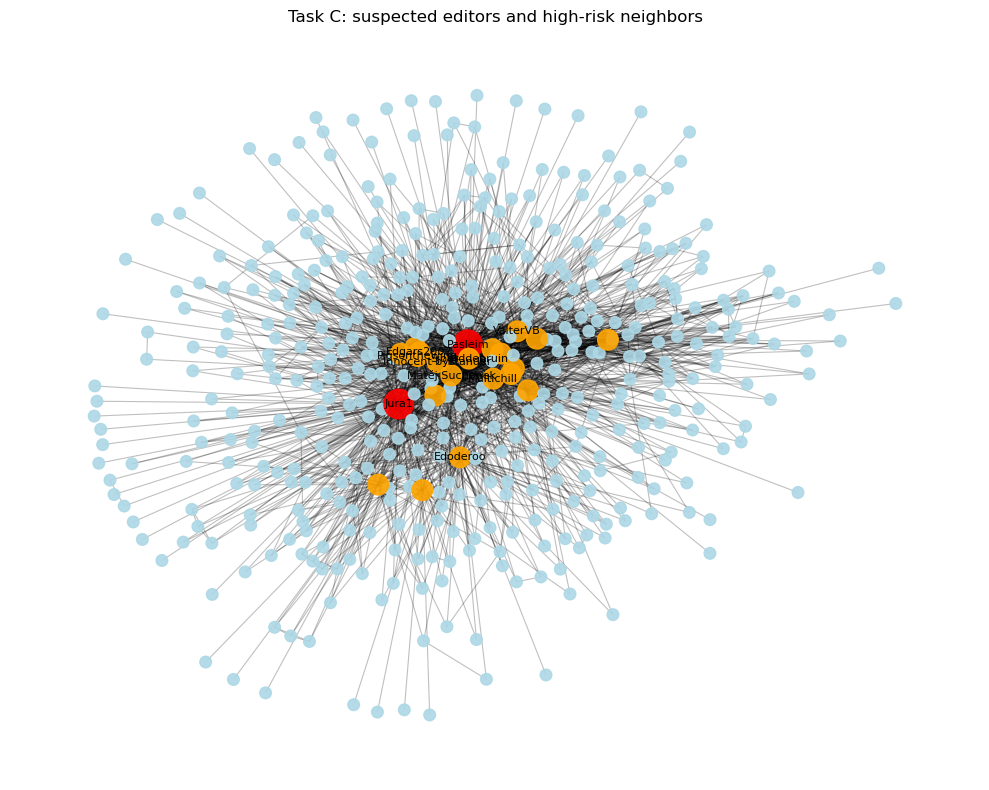

Suspected editors: ['Pasleim', 'Jura1']
Single-source non-propagation plausibility: Low
Single-source mean top risk: 0.5015
Dual-source non-propagation plausibility: High
Dual-source mean top risk: 0.3737


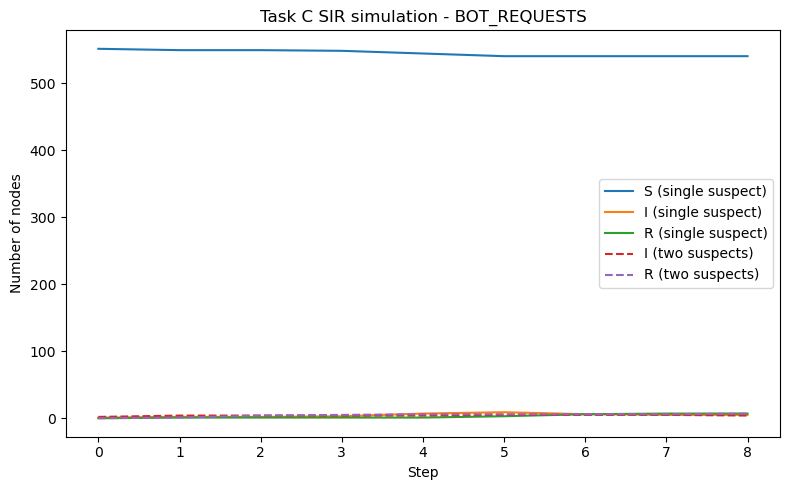


=== Task C: PROPERTIES ===


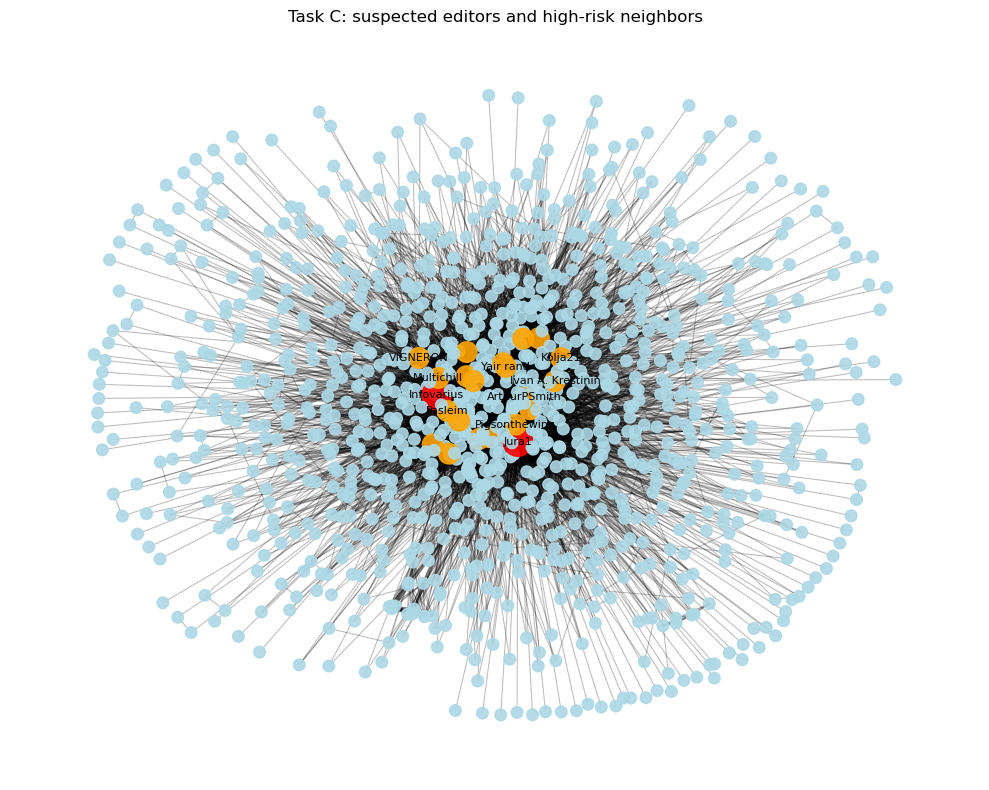

Suspected editors: ['Jura1', 'Infovarius']
Single-source non-propagation plausibility: Low
Single-source mean top risk: 0.782
Dual-source non-propagation plausibility: Low
Dual-source mean top risk: 0.7705


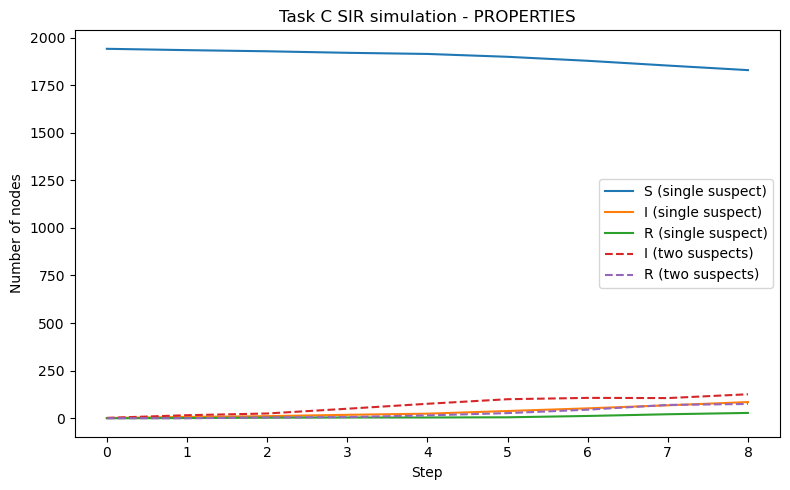


=== Task C: PROJECT_CHAT ===


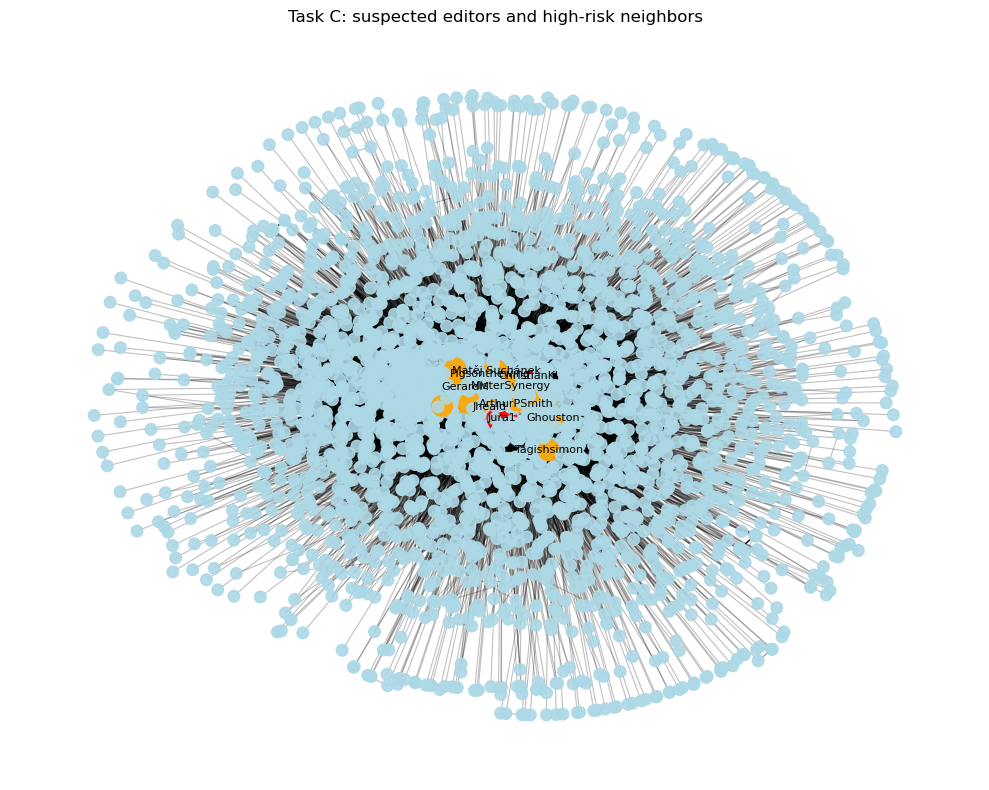

Suspected editors: ['Jura1', 'ChristianKl']
Single-source non-propagation plausibility: Low
Single-source mean top risk: 0.687
Dual-source non-propagation plausibility: Low
Dual-source mean top risk: 0.6466


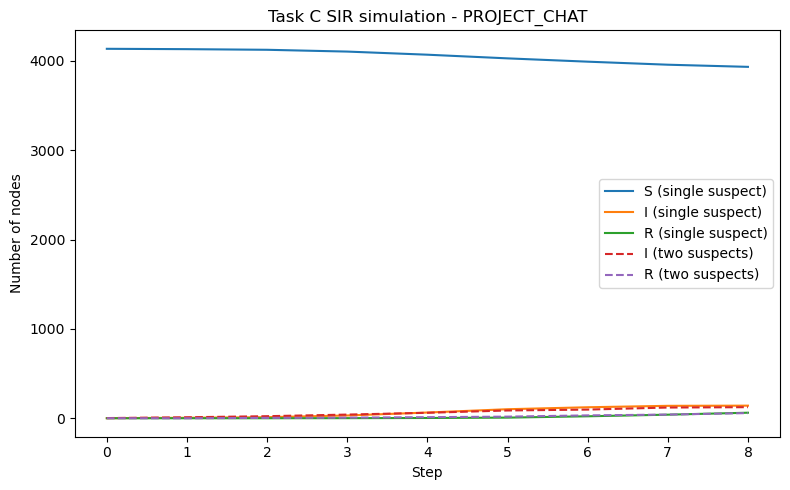


=== Task C Summary Table ===
        dataset suspected_user_1 suspected_user_2  \
0  BOT_REQUESTS          Pasleim            Jura1   
1    PROPERTIES            Jura1       Infovarius   
2  PROJECT_CHAT            Jura1      ChristianKl   

  single_non_propagation_plausibility  single_mean_top_risk  \
0                                 Low              0.501526   
1                                 Low              0.781998   
2                                 Low              0.686961   

  dual_non_propagation_plausibility  dual_mean_top_risk  
0                              High            0.373678  
1                               Low            0.770508  
2                               Low            0.646575  


In [6]:
files = {
    "BOT_REQUESTS": "./data/BOT_REQUESTS.csv",
    "PROPERTIES": "./data/PROPERTIES.csv",
    "PROJECT_CHAT": "./data/PROJECT_CHAT.csv"
}

results = {}

for name, path in files.items():
    print(f"Processing {name} ...")

    # G, df_clean, grouped, user_to_id, id_to_user = build_editor_network(path)
    G, df_clean, grouped, user_to_id, id_to_user, user_comment_count, user_discussion_count = build_editor_network(path)

    taskA_summary = compute_taskA_summary(G, df_clean, grouped)

    taskB_summary = compute_taskB_metrics(G, n_random=10, seed=42)

    results[name] = {
        "graph": G,
        "data": df_clean,
        "grouped": grouped,
        "taskA_summary": taskA_summary,
        "taskB_summary": taskB_summary,
        "user_to_id": user_to_id,
        "id_to_user": id_to_user,
        "user_comment_count": user_comment_count,
        "user_discussion_count": user_discussion_count
    }


# =========================================================
# 9. TASK A OUTPUTS
# =========================================================
taskA_df = pd.DataFrame(
    {name: res["taskA_summary"] for name, res in results.items()}
).T

taskA_df["largest_component_ratio"] = taskA_df["largest_component_ratio"].round(3)
taskA_df["density"] = taskA_df["density"].round(5)
taskA_df["avg_degree"] = taskA_df["avg_degree"].round(3)

print("\n=== Task A Summary Table ===")
print(taskA_df)

taskA_df.to_csv("part1_taskA_summary_table.csv", index=True)

plot_largest_components_combined(
    results,
    output_path="part1_taskA_largest_components.png",
    max_nodes_for_plot=200
)


# =========================================================
# 10. TASK B OUTPUTS
# =========================================================
taskB_df = pd.DataFrame(
    {name: res["taskB_summary"] for name, res in results.items()}
).T

for col in [
    "density", "avg_degree", "largest_component_ratio",
    "avg_clustering", "avg_shortest_path_lcc", "degree_std",
    "C_rand", "L_rand", "small_world_index"
]:
    taskB_df[col] = taskB_df[col].astype(float).round(4)

print("\n=== Task B Summary Table ===")
print(taskB_df)

taskB_df.to_csv("part1_taskB_summary_table.csv", index=True)

plot_degree_distributions(
    results,
    output_path="part1_taskB_degree_distributions.png"
)

plot_taskB_comparison(
    taskB_df,
    output_path="part1_taskB_real_vs_random.png"
)

# =========================================================
# 12. TASK C OUTPUTS
# =========================================================
taskC_results = {}

for name, res in results.items():
    print(f"\n=== Task C: {name} ===")

    G = res["graph"]
    id_to_user = res["id_to_user"]

    # Example suspects:
    # by default choose two highest-degree editors for a reproducible demonstration
    taskC_output = run_taskC_analysis_for_dataset(
        G=G,
        id_to_user=id_to_user,
        dataset_name=name,
        suspected_nodes=None,      # auto choose
        suspect_mode="top_degree", # or "random_connected"
        top_n_priority=20,
        save_prefix="part1_taskC"
    )

    taskC_results[name] = taskC_output

    print("Suspected editors:", taskC_output["suspected_usernames"])
    print("Single-source non-propagation plausibility:",
          taskC_output["single_plausibility"]["non_propagation_plausibility"])
    print("Single-source mean top risk:",
          round(taskC_output["single_plausibility"]["mean_top_risk"], 4))

    if taskC_output["dual_plausibility"] is not None:
        print("Dual-source non-propagation plausibility:",
              taskC_output["dual_plausibility"]["non_propagation_plausibility"])
        print("Dual-source mean top risk:",
              round(taskC_output["dual_plausibility"]["mean_top_risk"], 4))

    plot_taskC_sir_curves(
        taskC_output,
        dataset_name=name,
        output_path=f"part1_taskC_{name}_sir_curves.png"
    )

    # Save a short summary row
taskC_summary_rows = []

for name, out in taskC_results.items():
    row = {
        "dataset": name,
        "suspected_user_1": out["suspected_usernames"][0] if len(out["suspected_usernames"]) >= 1 else None,
        "suspected_user_2": out["suspected_usernames"][1] if len(out["suspected_usernames"]) >= 2 else None,
        "single_non_propagation_plausibility": out["single_plausibility"]["non_propagation_plausibility"],
        "single_mean_top_risk": out["single_plausibility"]["mean_top_risk"]
    }

    if out["dual_plausibility"] is not None:
        row["dual_non_propagation_plausibility"] = out["dual_plausibility"]["non_propagation_plausibility"]
        row["dual_mean_top_risk"] = out["dual_plausibility"]["mean_top_risk"]
    else:
        row["dual_non_propagation_plausibility"] = None
        row["dual_mean_top_risk"] = None

    taskC_summary_rows.append(row)

taskC_summary_df = pd.DataFrame(taskC_summary_rows)
taskC_summary_df.to_csv("part1_taskC_summary_table.csv", index=False)

print("\n=== Task C Summary Table ===")
print(taskC_summary_df)